In [17]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
#kagglehub.login()

In [ ]:
ucsc_cse_144_spring_2026_final_project_path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print('Data source import complete.')


OSError: Could not find a suitable TLS CA certificate bundle, invalid path: c:\Users\rachl\miniconda3\envs\cse144\lib\site-packages\certifi\cacert.pem

In [18]:
# Imports and Setup
import os, random
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, models, io
from PIL import Image
from torchvision.transforms import v2 as tfv2
from torch.utils.data import Dataset, DataLoader, random_split

device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    ''' For reproducible results across runs '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [11]:
# Load Training/Validation Data, transform, normalize, augment

data_dir = ucsc_cse_144_spring_2026_final_project_path + '/'
batch_size = 256 # doubled batch size
color_jitter_factor = 0.2
num_workers = 0 # for reproducibility
train_validation_ratio = 0.2
transforms = tfv2.Compose([
    tfv2.ToTensor(),
    tfv2.Resize((384,384), interpolation=tfv2.InterpolationMode.BILINEAR), # as reccomended by efficientnet v2 documentation
    tfv2.CenterCrop((384,384)),
    # Augmentations
    tfv2.RandomHorizontalFlip(),        # Flip Horizontal
    tfv2.RandomRotation(degrees=15),    # Rotate randomly up to 15 degrees
    tfv2.ColorJitter(brightness=color_jitter_factor, saturation=color_jitter_factor), # adjust color
    tfv2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_full = datasets.ImageFolder(root=data_dir+'train/', transform=transforms)
train_data, val_data = random_split(train_full, [1-train_validation_ratio, train_validation_ratio])
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val:", len(train_data), len(val_data))

train/val: 864 215


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
# Load pre-trained models

from torch.nn.modules import pooling
from torch.nn.modules.pooling import MaxUnpool2d

# using pre-trained model: EfficientNet V2 (M)
base_model = models.efficientnet_v2_s(weights='DEFAULT')

# freeze layers
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.classifier[1].in_features

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 157MB/s]


In [4]:
print(base_model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [21]:
# Rebuilding model
num_classes= 100
# fix last layer for now
base_model.classifier[1] = nn.Sequential(
                                        nn.Dropout(p=0.2, inplace=True), # Hyperparameters: p=0.2
                                        nn.Linear(in_features=num_ftrs, out_features=num_classes), # output resized to fit our dataset
                                        )

base_model = base_model.to(device)

In [22]:
# Load optimizers and criterion
import torch.optim as optim
optimizer = optim.Adam(base_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # cross entropy loss for classification

In [26]:
# Functions called for Training

def accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        prediction=output.argmax(1)
        total += label.size(0)
        correct += prediction.eq(label.view_as(prediction)).sum().item()

    return 100 * correct / total

def run_one_epoch(loader, model, epoch):
    model.train()
    total_loss = 0.0

    # unfreezing layers
    if epoch != 0 and epoch % 5 == 0: # every 5 epochs, unfreeze 3 more layers
        for i, params in enumerate(model.parameters()):
            if i >= (epoch / 5) * 3 + 1:
                break
            params.requires_grad = True

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad() # reset optimizer gradients
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc


In [24]:
# Validation Functions

def validate(loader, model):
    model.eval()
    total_loss = 0.0

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        loss = criterion(output, label)
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc

In [27]:
# Training and testing
num_epochs = 30
train_losses, train_accs = [], []
test_losses, test_accs  = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "/content/drive/MyDrive/cse144_final_project_checkpoints/best_2"

for epoch in range(num_epochs):
    train_loss, train_acc = run_one_epoch(loader=train_loader, model=base_model, epoch=epoch)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = validate(loader=val_loader,model=base_model)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch ({epoch})- Train Loss: {train_loss}, Train Acc: {train_acc}, Val Loss: {val_loss}, Val Acc: {val_acc}")

    if best_val_acc < val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save({'model_state_dict':base_model.state_dict(), 'epoch':epoch}, ckpt_path)

Epoch (0)- Train Loss: 4.480879545211792, Train Acc: 16.087962962962962, Val Loss: 4.2937493324279785, Val Acc: 8.837209302325581


KeyboardInterrupt: 

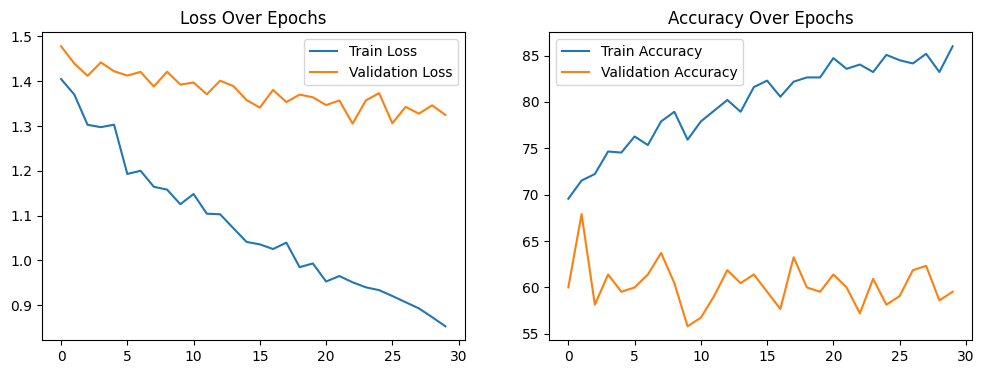

In [19]:
# Plot loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

In [12]:
class TestSet(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(os.listdir(self.root_dir))

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_id = f"{idx}.jpg"
        img_path = os.path.join(self.root_dir, img_id)
        sample = Image.open(img_path)

        if self.transform:
            sample = self.transform(sample)

        return sample, img_id


In [20]:
# Testing, save results as .csv file with imgID | class
import csv
ckpt_path = "/content/drive/MyDrive/cse144_final_project_checkpoints/best_2"
data_dir = ucsc_cse_144_spring_2026_final_project_path + '/'
num_classes = 100

# Load the model
model = models.efficientnet_v2_s(weights='DEFAULT')
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(nn.Dropout(p=0.2, inplace=True),
                                        nn.Linear(in_features=num_ftrs, out_features=num_classes) # output resized to fit our dataset
                                        )
model = model.to(device)

state_dict = torch.load(ckpt_path, map_location='cpu')['model_state_dict']
model.load_state_dict(state_dict)
model.eval()

num_workers = 0
test_transforms = tfv2.Compose([
    tfv2.ToTensor(),
    tfv2.Resize((384,384), interpolation=tfv2.InterpolationMode.BILINEAR), # as reccomended by efficientnet v2 documentation
    tfv2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_set = TestSet(root_dir=data_dir+'test', transform=test_transforms)
test_loader = DataLoader(test_set, batch_size=1, num_workers=num_workers, shuffle=False)

with open('submission.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['ID', 'Label']) # HEADER
    with torch.no_grad():
        for input, id in test_loader:
            input = input.to(device)
            id = id[0]
            output = model(input)
            writer.writerow([id, torch.argmax(output, dim=1).item()])


RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Missing key(s) in state_dict: "features.7.0.weight", "features.7.1.weight", "features.7.1.bias", "features.7.1.running_mean", "features.7.1.running_var". 
	Unexpected key(s) in state_dict: "features.8.0.weight", "features.8.1.weight", "features.8.1.bias", "features.8.1.running_mean", "features.8.1.running_var", "features.8.1.num_batches_tracked", "features.1.2.block.0.0.weight", "features.1.2.block.0.1.weight", "features.1.2.block.0.1.bias", "features.1.2.block.0.1.running_mean", "features.1.2.block.0.1.running_var", "features.1.2.block.0.1.num_batches_tracked", "features.2.4.block.0.0.weight", "features.2.4.block.0.1.weight", "features.2.4.block.0.1.bias", "features.2.4.block.0.1.running_mean", "features.2.4.block.0.1.running_var", "features.2.4.block.0.1.num_batches_tracked", "features.2.4.block.1.0.weight", "features.2.4.block.1.1.weight", "features.2.4.block.1.1.bias", "features.2.4.block.1.1.running_mean", "features.2